In [3]:
/jarvis refactoriza este codigo
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)
n = 300

x = np.random.randn(n)
y = np.random.randn(n)
z = 0.6 * x + 0.2 * y + np.random.randn(n)

```markdown
Aquí tienes una versión refactorizada del código:

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def generate_data(seed=42, n_samples=300):
    np.random.seed(seed)
    
    x = np.random.randn(n_samples)
    y = np.random.randn(n_samples)
    z = 0.6 * x + 0.2 * y + np.random.randn(n_samples)
    
    return x, y, z

x, y, z = generate_data()
```

En esta versión refactorizada:

1. Se encapsula la generación de datos en una función `generate_data` para mejorar la reutilización del código.
2. Los parámetros `seed` y `n_samples` se definen con valores por defecto, lo que permite personalizarlos fácilmente si se desea generar conjuntos de datos diferentes o de tamaños distintos.
3. La función devuelve las variables `x`, `y`, y `z`, lo que facilita su uso posterior en el código.

Esta refactorización hace que el código sea más modular y fácil de mantener.

In [5]:
datos_3d = np.column_stack((x, y, z))
print(datos_3d.shape)

(300, 3)


In [6]:
pca = PCA(n_components=2)

datos_2d = pca.fit_transform(datos_3d)
varianza_explicada = pca.explained_variance_ratio_
varianza_total = varianza_explicada.sum()

print(f"Dimensiones originales: {datos_3d.shape[1]}")
print(f"Nuevas dimensiones: {datos_2d.shape[1]}")
print(f"Varianza explicada por componente: {np.round(varianza_explicada, 2)}")
print(f"Varianza total conservada con 2 componentes: {varianza_total:.2f}")

Dimensiones originales: 3
Nuevas dimensiones: 2
Varianza explicada por componente: [0.53 0.3 ]
Varianza total conservada con 2 componentes: 0.83


In [7]:
eigenvalores = pca.explained_variance_
print(f"Eigenvalores (varianza explicada): {np.round(eigenvalores, 2)}")

eigenvectores = pca.components_
print(f"Eigenvectores (componentes principales): {np.round(eigenvectores, 2)}")

Eigenvalores (varianza explicada): [1.71 0.95]
Eigenvectores (componentes principales): [[ 0.58  0.11  0.81]
 [-0.29  0.95  0.08]]


/tmp/ipykernel_504/368014824.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(datos_3d[:, 0], datos_3d[:, 1], datos_3d[:, 2], cmap='viridis', alpha=0.7)
/tmp/ipykernel_504/368014824.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(datos_2d[:, 0], datos_2d[:, 1], cmap='viridis', alpha=0.7)


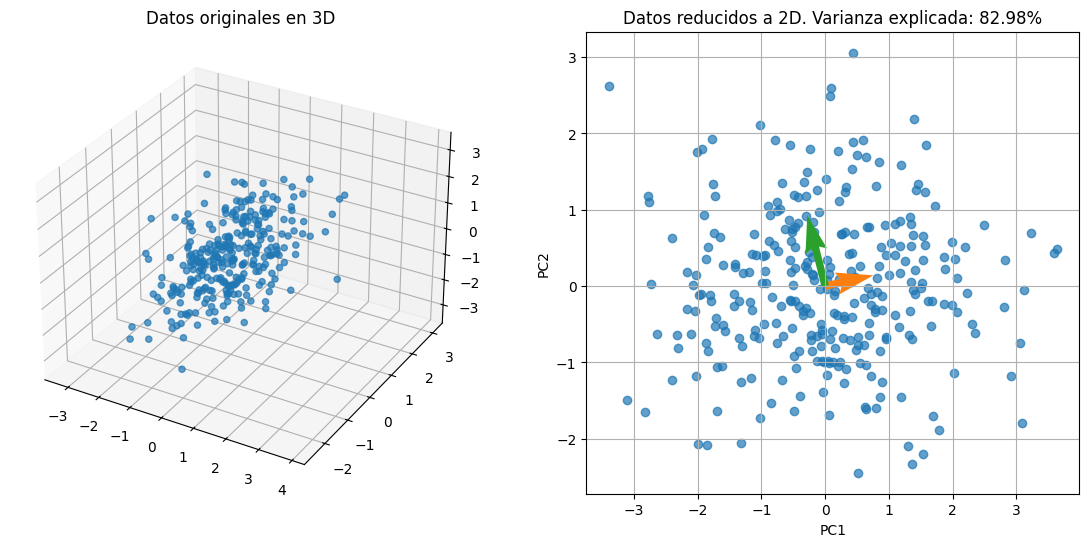

In [8]:
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(datos_3d[:, 0], datos_3d[:, 1], datos_3d[:, 2], cmap='viridis', alpha=0.7)
ax1.set_title("Datos originales en 3D")

longitud1 = np.sqrt(eigenvalores[0])
longitud2 = np.sqrt(eigenvalores[1])

ax2 = fig.add_subplot(122)
ax2.scatter(datos_2d[:, 0], datos_2d[:, 1], cmap='viridis', alpha=0.7)
ax2.quiver(0,0, eigenvectores[0][0] * longitud1, eigenvectores[0][1] * longitud1, angles='xy', scale_units='xy', scale=1, color=f'C1',width=0.015)
ax2.quiver(0,0, eigenvectores[1][0] * longitud2, eigenvectores[1][1] * longitud2, angles='xy', scale_units='xy', scale=1, color=f'C2',width=0.015)
ax2.set_title(f"Datos reducidos a 2D. Varianza explicada: {varianza_total:.2%}")
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.grid(True)
plt.show()

In [1]:
jarvis